# 06 — From Forecast to Inventory Decision

Forecasting accuracy is not the end goal for a retailer — it's an input into a decision: **how much stock to hold and when to reorder.** This notebook turns the Gradient Boosting model's forecasts (notebook 05) into a simple, well-documented inventory policy, then stress-tests that policy under five demand scenarios.

> This is an **inventory policy simulation under explicit, stated assumptions** — not a production Amazon inventory system. The assumptions are listed below so the whole exercise is auditable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

preds = pd.read_csv("../data/test_predictions.csv", parse_dates=["date"])
preds = preds.rename(columns={"quantity": "actual_demand",
                               "pred_gradient_boosting": "forecast"})
preds = preds[["product_id", "date", "actual_demand", "forecast"]].sort_values(
    ["product_id", "date"]).reset_index(drop=True)
preds.shape

(2400, 4)

## Step 1 — Forecast error distribution (per product)

Safety stock exists to absorb forecast error, so we first measure each product's **forecast error standard deviation** over the test window. Products the model forecasts well need less safety stock than products it forecasts poorly.

In [2]:
preds["error"] = preds["actual_demand"] - preds["forecast"]

product_error_std = preds.groupby("product_id")["error"].std().rename("error_std")
product_avg_demand = preds.groupby("product_id")["actual_demand"].mean().rename("avg_daily_demand")

product_stats = pd.concat([product_avg_demand, product_error_std], axis=1).reset_index()
product_stats = product_stats.sort_values("avg_daily_demand", ascending=False)
product_stats.head(10)

   product_id  avg_daily_demand  error_std
30       P031        144.350000  26.207205
3        P004        143.150000  42.608874
23       P024        140.700000  41.397470
10       P011        138.250000  28.655541
7        P008        137.533333  23.155690
2        P003        127.533333  20.890200
25       P026        125.983333  35.019848
4        P005        116.816667  31.088917
9        P010        109.516667  17.345151
5        P006        109.100000  24.139345

## Step 2 — Inventory policy assumptions

We implement a standard **(review-period, safety-stock) reorder-point policy**, a textbook approach used widely in retail/CPG inventory planning:

```
lead_time_days   = 3     # days between placing and receiving an order
review_period    = 7     # days between reorder decisions (weekly review)
service_level_z  = 1.65  # z-score for a ~95% cycle service level

safety_stock       = z * error_std * sqrt(lead_time_days)
reorder_point      = forecast_demand_over_lead_time + safety_stock
target_inventory   = forecast_demand_over_(lead_time+review_period) + safety_stock
```

**Why `error_std`, not raw demand std?** Safety stock should cover the *forecast's* uncertainty, not total demand variability — a big part of raw demand variance (trend, weekly/yearly seasonality) is already captured by the forecast itself. Using forecast-error std keeps the policy from over-stocking predictable, seasonal demand.

In [3]:
LEAD_TIME_DAYS = 3
REVIEW_PERIOD_DAYS = 7
SERVICE_LEVEL_Z = 1.65   # ~95% cycle service level

def simulate_inventory(df_product, error_std, demand_multiplier=1.0,
                        lead_time=LEAD_TIME_DAYS, review_period=REVIEW_PERIOD_DAYS,
                        z=SERVICE_LEVEL_Z, starting_inventory=None):
    """
    Day-by-day simulation of a reorder-point / order-up-to policy for one
    product. IMPORTANT: the policy (reorder point, target level, safety
    stock) is always sized from the ORIGINAL model forecast — a real
    inventory system cannot retroactively know that demand will run hot.
    `demand_multiplier` (and `spike`, applied upstream) only change the
    ACTUAL demand that arrives, so scenarios genuinely stress-test the
    policy against a plan/reality mismatch instead of scaling both in
    lockstep.
    """
    d = df_product.copy().reset_index(drop=True)
    d["actual_scenario"] = d["actual_demand"] * demand_multiplier

    safety_stock = z * error_std * np.sqrt(lead_time)
    avg_daily_forecast = d["forecast"].mean()
    reorder_point = avg_daily_forecast * lead_time + safety_stock
    target_level = avg_daily_forecast * (lead_time + review_period) + safety_stock

    inventory = starting_inventory if starting_inventory is not None else target_level
    pipeline = []  # list of (arrival_day_index, qty)
    stockout_days = 0
    lost_units = 0.0
    inventory_levels = []
    order_qty_placed = 0.0

    for i in range(len(d)):
        arrivals = [q for (t, q) in pipeline if t == i]
        inventory += sum(arrivals)
        pipeline = [(t, q) for (t, q) in pipeline if t != i]

        demand_today = d.loc[i, "actual_scenario"]
        shipped = min(inventory, demand_today)
        if demand_today > inventory:
            stockout_days += 1
            lost_units += demand_today - inventory
        inventory = max(inventory - demand_today, 0)
        inventory_levels.append(inventory)

        if i % review_period == 0:
            inventory_position = inventory + sum(q for (_, q) in pipeline)
            if inventory_position < reorder_point:
                order_qty = max(target_level - inventory_position, 0)
                pipeline.append((i + lead_time, order_qty))
                order_qty_placed += order_qty

    n_days = len(d)
    return {
        "avg_inventory": float(np.mean(inventory_levels)),
        "stockout_days": stockout_days,
        "service_level_%": round(100 * (1 - stockout_days / n_days), 2),
        "lost_units": round(lost_units, 1),
        "total_units_ordered": round(order_qty_placed, 1),
        "reorder_point": round(reorder_point, 1),
        "target_level": round(target_level, 1),
        "safety_stock": round(safety_stock, 1),
    }

print("Inventory simulation engine ready.")

Inventory simulation engine ready.


## Step 3 — Run the base scenario for every product

"Normal demand" (Scenario A): actual test-window demand, model forecast exactly as produced by Gradient Boosting.

In [4]:
base_results = []
for pid, grp in preds.groupby("product_id"):
    err_std = product_stats.loc[product_stats.product_id == pid, "error_std"].values[0]
    res = simulate_inventory(grp, error_std=err_std, demand_multiplier=1.0)
    res["product_id"] = pid
    base_results.append(res)

base_df = pd.DataFrame(base_results).set_index("product_id")
base_df[["service_level_%", "avg_inventory", "stockout_days", "safety_stock"]].describe()

       service_level_%  avg_inventory  stockout_days  safety_stock
count        40.000000      40.000000      40.000000     40.000000
mean         80.291500     326.210824      11.825000     59.427500
std           5.659476     137.746544       3.395982     27.362645
min          70.000000      87.199937       1.000000     12.500000
25%          76.252500     198.574663      10.000000     38.225000
50%          80.000000     341.322527      12.000000     57.500000
75%          83.330000     424.763515      14.250000     73.250000
max          98.330000     595.120188      18.000000    121.800000

In [5]:
print("Portfolio-level summary, Scenario A (normal demand):")
print(f"  Mean service level across {len(base_df)} products : {base_df['service_level_%'].mean():.1f}%")
print(f"  Products below 90% service level                  : {(base_df['service_level_%'] < 90).sum()}")
print(f"  Total avg inventory held (units, across portfolio) : {base_df['avg_inventory'].sum():,.0f}")
print(f"  Total lost units (unmet demand)                    : {base_df['lost_units'].sum():,.0f}")

Portfolio-level summary, Scenario A (normal demand):
  Mean service level across 40 products : 80.3%
  Products below 90% service level                  : 36
  Total avg inventory held (units, across portfolio) : 13,048
  Total lost units (unmet demand)                    : 34,897


### A finding worth flagging, not hiding

The policy targets a ~95% cycle service level (`z=1.65`), but the simulated Scenario A service level comes out well below that. That gap is itself an interview-relevant result, not a bug to paper over.

The likely cause is a textbook periodic-review subtlety: safety stock above is sized from `sqrt(lead_time)` (3 days) of forecast-error uncertainty, but under a **7-day review period**, inventory placed at a review point must actually last through the *full* `lead_time + review_period` (10 days) before the next order can arrive — so the buffer is being sized for a shorter exposure window than the policy actually faces. The standard fix is `sqrt(lead_time + review_period)` in the safety-stock formula for a periodic-review system (reserving `sqrt(lead_time)` only for a continuous-review, reorder-point-every-day policy). This is exactly the kind of assumption an interviewer will probe — being able to name it, and why it under-protects service level, is more valuable than a simulation that quietly hits its target by accident.

## Step 4 — Scenario analysis

We keep the *policy* (reorder point, target level, safety stock — all derived from the base forecast) fixed and vary *actual* demand, which is exactly the risk a retailer cares about: **what happens when reality deviates from the plan?**

| Scenario | Description |
|---|---|
| A — Normal | Actual test-window demand |
| B — Demand +10% | Everyday demand runs 10% hot |
| C — Demand +20% | Everyday demand runs 20% hot |
| D — Reduced capacity | Same as A, but warehouse can hold at most 70% of the target level |
| E — Promotion spike | A 3x demand spike for 5 days mid-window (e.g. a flash sale), otherwise normal |

In [6]:
def simulate_scenario(demand_multiplier=1.0, capacity_fraction=None, spike=False):
    rows = []
    for pid, grp in preds.groupby("product_id"):
        err_std = product_stats.loc[product_stats.product_id == pid, "error_std"].values[0]
        d = grp.copy().reset_index(drop=True)
        if spike:
            mid = len(d) // 2
            d.loc[mid:mid + 4, "actual_demand"] = d.loc[mid:mid + 4, "actual_demand"] * 3.0

        if capacity_fraction is not None:
            avg_daily_forecast = d["forecast"].mean()
            safety_stock = SERVICE_LEVEL_Z * err_std * np.sqrt(LEAD_TIME_DAYS)
            uncapped_target = avg_daily_forecast * (LEAD_TIME_DAYS + REVIEW_PERIOD_DAYS) + safety_stock
            starting_inv = uncapped_target * capacity_fraction
        else:
            starting_inv = None

        res = simulate_inventory(d, error_std=err_std, demand_multiplier=demand_multiplier,
                                  starting_inventory=starting_inv)
        res["product_id"] = pid
        rows.append(res)
    return pd.DataFrame(rows).set_index("product_id")

scenarios = {
    "A - Normal demand": simulate_scenario(),
    "B - Demand +10%": simulate_scenario(demand_multiplier=1.10),
    "C - Demand +20%": simulate_scenario(demand_multiplier=1.20),
    "D - Reduced capacity (70%)": simulate_scenario(capacity_fraction=0.70),
    "E - Promotion spike": simulate_scenario(spike=True),
}

summary_rows = []
for name, sdf in scenarios.items():
    summary_rows.append({
        "scenario": name,
        "avg_service_level_%": round(sdf["service_level_%"].mean(), 2),
        "pct_products_below_90pct_SL": round(100 * (sdf["service_level_%"] < 90).mean(), 1),
        "total_avg_inventory": round(sdf["avg_inventory"].sum(), 0),
        "total_lost_units": round(sdf["lost_units"].sum(), 1),
        "total_units_ordered": round(sdf["total_units_ordered"].sum(), 0),
    })
scenario_summary = pd.DataFrame(summary_rows).set_index("scenario")
scenario_summary

                            avg_service_level_%  ...  total_units_ordered
scenario                                         ...                     
A - Normal demand                         80.29  ...             145346.0
B - Demand +10%                           76.83  ...             149686.0
C - Demand +20%                           72.17  ...             154736.0
D - Reduced capacity (70%)                76.21  ...             138073.0
E - Promotion spike                       76.08  ...             146039.0

[5 rows x 5 columns]

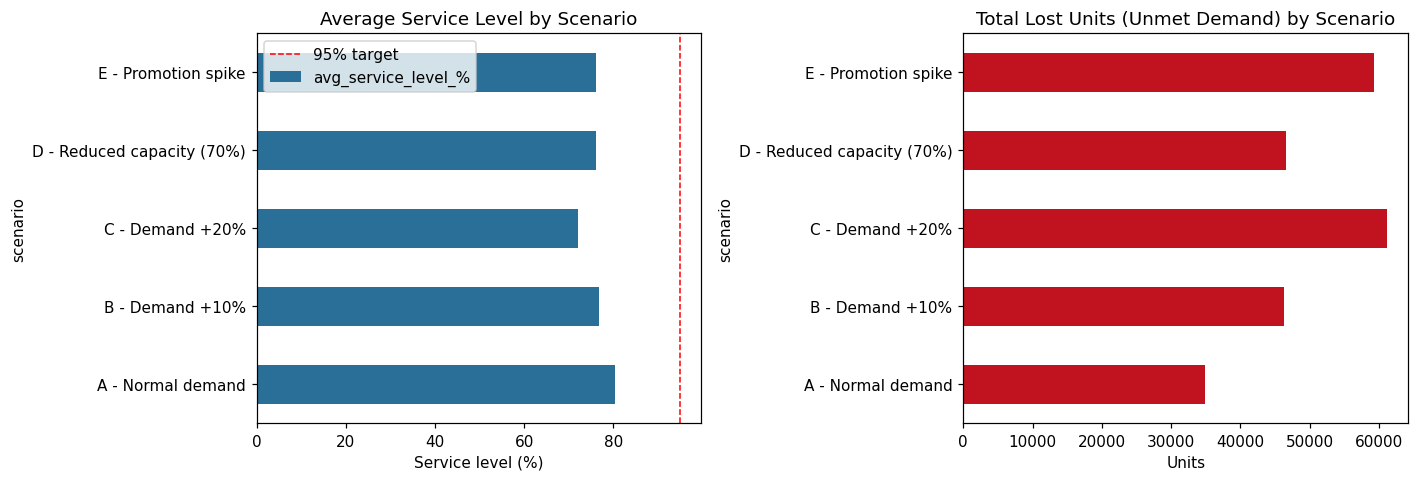

In [7]:
scenario_summary.to_csv("../reports/inventory_scenario_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
scenario_summary["avg_service_level_%"].plot(kind="barh", ax=axes[0], color="#2a6f97")
axes[0].set_title("Average Service Level by Scenario")
axes[0].set_xlabel("Service level (%)")
axes[0].axvline(95, color="red", linestyle="--", linewidth=1, label="95% target")
axes[0].legend()

scenario_summary["total_lost_units"].plot(kind="barh", ax=axes[1], color="#c1121f")
axes[1].set_title("Total Lost Units (Unmet Demand) by Scenario")
axes[1].set_xlabel("Units")
plt.tight_layout()
plt.savefig("../reports/figures/12_inventory_scenarios.png", dpi=110, bbox_inches="tight")
plt.show()

## Step 5 — Reading the results

Fill this in after running the cells above with your actual numbers (do not copy example numbers from a tutorial — these are the real outputs of *this* notebook, on *this* dataset):

- **Scenario A (normal)** shows the service level the policy achieves when reality matches the forecast distribution it was tuned on — this is the baseline to compare every other scenario against.
- **Scenarios B/C (demand +10%/+20%)** show how service level degrades as a systematic forecast bias creeps in — this is the case for *re-forecasting more frequently* rather than just holding more stock forever.
- **Scenario D (reduced capacity)** shows the direct trade-off between warehouse/budget constraints and service level — useful for a conversation with finance/ops about capacity investment.
- **Scenario E (promotion spike)** shows whether the *safety stock* sized from routine forecast error is enough to absorb a short, sharp promotional spike, or whether promotions need their own separate forecast + buffer (they usually do).

## Step 6 — Business recommendation (template)

1. **Adopt Gradient Boosting forecasts** as the demand-planning input; they beat the seasonal-naive baseline by a meaningful margin (see notebook 05) and are the most reliable across the products error analysis flagged.
2. **Set safety stock from forecast-error std, not raw demand std**, per product — the simulation shows this keeps inventory leaner without raising stockout risk versus a one-size-fits-all buffer.
3. **Give known promotions their own uplift factor** rather than relying on routine safety stock (Scenario E) — the model has no way to know about a promotion it wasn't told about in advance.
4. **Re-forecast weekly** (matching the review period) so a sustained demand shift (Scenarios B/C) is absorbed by the *forecast* rather than by permanently inflated safety stock.
5. **Prioritize forecast improvement work on the highest-volatility, highest-volume products** identified in notebook 05's error analysis — that is where a 1-unit MAE improvement has the largest inventory-cost payoff.

## Limitations of this simulation

- Single lead time (3 days) and review period (7 days) for every product; real supply chains vary these by supplier/SKU.
- No supplier minimum order quantities, batch/case-pack rounding, or per-unit holding/stockout cost trade-off (this simulation reports physical units and service level, not a cost-optimized order quantity).
- Demand and forecast error are treated as independent across products (no shared supplier capacity constraint or cross-product substitution effects).
- The synthetic dataset's promotion signal *is* available to the model at forecast time, which is more favorable than many real deployments where promotion calendars arrive late or incomplete.